
# Optimización de Redes Neuronales

**Estudiante:** Yohan Nicolás Gómez Castañeda  
**Universidad:** Universidad de Cundinamarca  
**Programa:** Especialización en Inteligencia Artificial  
**Fecha:** 19 de marzo de 2026  

---

## Objetivo
Comparar el rendimiento de una red neuronal utilizando dos técnicas de optimización: SGD y Adam.


In [1]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers


## Dataset

In [2]:

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Modelos

In [3]:

# Modelo sin regularización
def modelo_base():
    return tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

# Modelo con Dropout
def modelo_dropout():
    return tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

# Modelo con L2
def modelo_l2():
    return tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu',
                              kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])


## Entrenamiento

In [4]:

base = modelo_base()
base.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_base = base.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

drop = modelo_dropout()
drop.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_drop = drop.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

l2 = modelo_l2()
l2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_l2 = l2.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9275 - loss: 0.2546 - val_accuracy: 0.9618 - val_loss: 0.1281
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9682 - loss: 0.1092 - val_accuracy: 0.9718 - val_loss: 0.0941
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9773 - loss: 0.0755 - val_accuracy: 0.9741 - val_loss: 0.0844
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9829 - loss: 0.0559 - val_accuracy: 0.9765 - val_loss: 0.0792
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9860 - loss: 0.0444 - val_accuracy: 0.9759 - val_loss: 0.0813
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8850 - loss: 0.3910 - val_accuracy: 0.9499 - val_loss: 0.1673
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9335 - loss: 0.2235 - val_accuracy: 0.9627 - val_loss: 0.1287
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9457 - loss: 0.1837 - val_ac

## Comparación

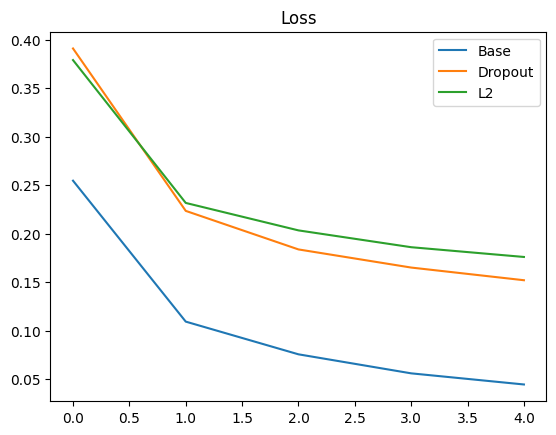

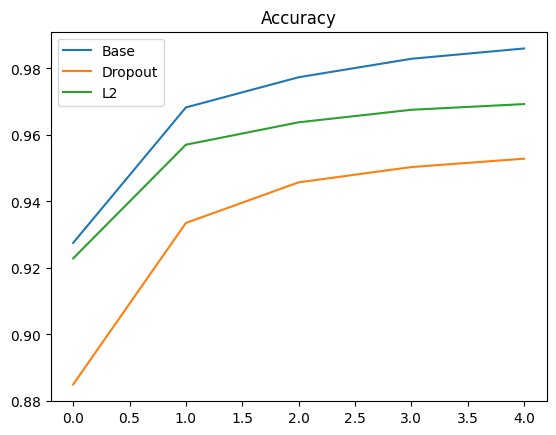

In [5]:

plt.plot(h_base.history['loss'], label='Base')
plt.plot(h_drop.history['loss'], label='Dropout')
plt.plot(h_l2.history['loss'], label='L2')
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(h_base.history['accuracy'], label='Base')
plt.plot(h_drop.history['accuracy'], label='Dropout')
plt.plot(h_l2.history['accuracy'], label='L2')
plt.legend()
plt.title("Accuracy")
plt.show()



## Análisis

Se evidencia overfitting en el modelo base al comparar entrenamiento y validación.  
Dropout reduce este problema al apagar neuronas aleatoriamente.  
L2 penaliza los pesos grandes, logrando un modelo más estable.

Ambas técnicas mejoran la generalización.



## Conclusión

Las técnicas de regularización como Dropout y L2 mejoran significativamente el rendimiento del modelo, reduciendo el sobreajuste y aumentando la capacidad de generalización.
